In [1]:
# Define the path to the configuration file for the embedding pipeline
config_file_path = "data/configs/embeddings/200_de_embedding_config.yaml"

In [2]:
# Runs the embedding pipeline with the specified configuration file
from ml_filter.annotation.embedding_pipeline import run_embedding_pipeline
from pathlib import Path

run_embedding_pipeline(Path(config_file_path))

/raid/s3/opengptx/mehdi-ali/git_repos/ml_filter/mlfilter_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-19 14:43:56.280789: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-19 14:43:56.292677: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763559836.306646 3395392 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763559836.31

Running Local Pipeline Executor


2025-11-19 14:43:57.684 | INFO     | datatrove.utils.logging:add_task_logger:58 - Launching pipeline for rank=0
2025-11-19 14:43:57.685 | INFO     | datatrove.utils.logging:log_pipeline:90 - 
--- 🛠️ PIPELINE 🛠
📖 - READER: 🐿 Jsonl
🔢 - JQL-EMBEDDER: 🔢 - JQL-EMBEDDER
2025-11-19 14:44:07.587 | INFO     | datatrove.pipeline.readers.base:read_files_shard:201 - Reading input file 200_de.jsonl, 1/1
2025-11-19 14:44:07.588 | INFO     | ml_filter.annotation.datatrove_jql_annotator:read_file:141 - Reading file %s
2025-11-19 14:44:07.589 | INFO     | ml_filter.annotation.datatrove_jql_annotator:read_file:142 - data folder %s
2025-11-19 14:44:07.589 | ERROR    | datatrove.executor.base:_run_for_rank:108 - No 'score' field found in document metadata to copy to 'label'.
Traceback (most recent call last):

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/raid/s3/opengptx/mehdi-ali/git_repos/ml_filter/mlfilter_venv/lib/python3.11/site-pac

ValueError: No 'score' field found in document metadata to copy to 'label'.

In [23]:
# Load embeddings
import h5py
import yaml
from pathlib import Path
import numpy as np

with open(config_file_path, "r") as f:
        config = yaml.safe_load(f)

output_dir = config["params"]["output_dir"]
embedding_dir = Path(output_dir) / config["params"]["embedding_dir"]

hdf5_files = sorted(list(embedding_dir.glob("*.h5")))

embeddings = []

for file_path in hdf5_files:
    with h5py.File(file_path, "r") as f:
        # get dataset name
        key = list(f.keys())[0]      
        embedding = f[key]["embeddings"][:]
        embeddings.append(embedding)
            

# Concatenate all embeddings into one numpy array (optional)
all_embeddings = np.vstack(embeddings)

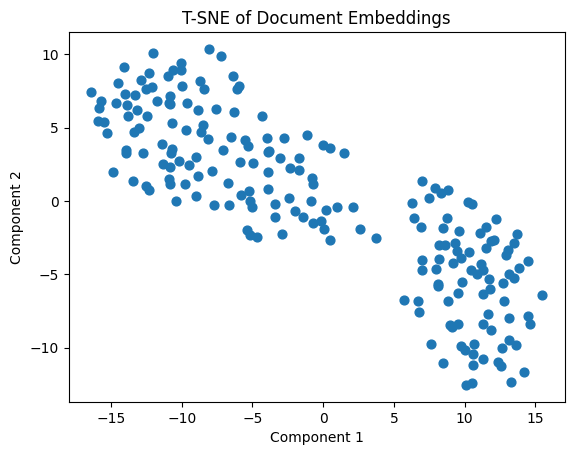

In [20]:
# Plot embeddings
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30,         
    learning_rate="auto",
    init="random",
    random_state=42,
)

emb_2d = tsne.fit_transform(all_embeddings)

plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=40)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title("T-SNE of Document Embeddings")
plt.show()